# Test of bundle adjustment module.

In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import os, sys
root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

import torch 
import torch.nn.functional as F
import numpy as np
import math
import time
from box import Box
import yaml
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

# choose version on bundle adjustment 
from src.models.bundle_adjustment_v2 import BundleAdjustment

from src.models.utils import project_points

import pandas as pd


## Generate synthetic data.


In [14]:
def generate_data_from_csv(csv_path, n_poses, n_pts, device, freeze_poses, sonar_param,
                           trans_noise_power = 0.3, rot_noise_power = 0.01):
   
    # read data from csv
    df = pd.read_csv(csv_path)

    actual_n_poses = min(n_poses, len(df))
    poses_gt_np = df[['pos_x', 'pos_y', 'pos_z', 'quat_x', 'quat_y', 'quat_z', 'quat_w']].values[:actual_n_poses]
    
    poses_gt = torch.tensor(poses_gt_np, dtype=torch.float32, device=device).unsqueeze(0)
    poses_gt[:, :, 3:] = F.normalize(poses_gt[:, :, 3:], p=2.0, dim=-1)

    # calculate noise power, based on actual data
    if actual_n_poses > 1:
        trans_steps = torch.norm(poses_gt[:, 1:, :3] - poses_gt[:, :-1, :3], dim=-1)
        mean_trans_step = trans_steps.mean().item()
    else:
        mean_trans_step = 0.1 

    
    # set translation noise power as trans_noise_power % of step
    # set rotation nosie power to value rot_noise_power
    pose_noise_max_trans = mean_trans_step * trans_noise_power
    pose_noise_max_rot = rot_noise_power

    r_min = sonar_param.range.min
    r_max = sonar_param.range.max

    theta_min = -sonar_param.fov.horizontal / 2 
    theta_max = sonar_param.fov.horizontal / 2

    phi_min = -sonar_param.position.pitch 
    phi_max = phi_min - sonar_param.fov.vertical
    
    scale_factor = torch.tensor([sonar_param.resolution.bins / (sonar_param.range.max - sonar_param.range.min),
                                 sonar_param.resolution.beams / sonar_param.fov.horizontal], device=device).view(1, 2)
    
    # Generate noise trajecty
    n_noisy = actual_n_poses - freeze_poses
    
    # Random err for each step 
    step_noise_t = (torch.rand((1, n_noisy, 3), device=device) - 0.5) * 2.0 * pose_noise_max_trans
    step_noise_r = (torch.rand((1, n_noisy, 4), device=device) - 0.5) * 2.0 * pose_noise_max_rot
    
    # Accumulate along trajectory
    drift_t = torch.cumsum(step_noise_t, dim=1)
    drift_r = torch.cumsum(step_noise_r, dim=1)

    poses_noise_t = poses_gt[:, freeze_poses:, :3] + drift_t
    poses_noise_r = poses_gt[:, freeze_poses:, 3:] + drift_r

    poses_noise_tail = torch.cat([poses_noise_t, poses_noise_r], dim=-1)
    poses_noise = torch.cat([poses_gt[:, :freeze_poses, :], poses_noise_tail], dim=1)
    poses_noise[:, :, 3:] = F.normalize(poses_noise[:, :, 3:], p=2.0, dim=-1)

    # Generate random patches that are tracked 
    r = torch.rand(1, actual_n_poses, n_pts, 1, device=device) * (r_max - r_min) + r_min
    theta = torch.rand(1, actual_n_poses, n_pts, 1, device=device) * (theta_max - theta_min) + theta_min
    phi = torch.rand(1, actual_n_poses, n_pts, 1, device=device) * (phi_max - phi_min) + phi_min

    coords_r_theta = torch.cat([r, theta], dim=-1)
    coords_stack = torch.cat([r, theta, phi], dim=-1)
    
    # Generate graph edges
    new_i, new_j = [], [] 
    for sf in range(actual_n_poses): # for each source frame
        for tf in range(actual_n_poses): # for each target frame
            if sf != tf: 
                # edges: new patches -> old frames
                new_i.append(torch.arange(sf * n_pts, (sf + 1) * n_pts, device=device)) 
                new_j.append(torch.full((n_pts,), tf, device=device))
                
                # edges: old patches -> new frame
                # new_i.append(torch.arange(tf * n_pts, (tf + 1) * n_pts, device=device))
                # new_j.append(torch.full((n_pts,), sf, device=device))

    i = torch.cat(new_i, dim=0)
    j = torch.cat(new_j, dim=0)
    edges_num = i.shape[0]

    source_poses_idx = i // n_pts
    patch_idx = i
    target_poses_idx = j 
    
    source_coords = coords_stack.view(actual_n_poses * n_pts, 3)[patch_idx]
    
    source_poses_gt = poses_gt.view(actual_n_poses, 7)[source_poses_idx]
    target_poses_gt = poses_gt.view(actual_n_poses, 7)[target_poses_idx]
    
    projection_gt = project_points(source_coords, source_poses_gt, target_poses_gt)   

    source_poses_noise = poses_noise.view(actual_n_poses, 7)[source_poses_idx]
    target_poses_noise = poses_noise.view(actual_n_poses, 7)[target_poses_idx]
    
    projection_noise = project_points(source_coords, source_poses_noise, target_poses_noise)  
                
    delta = (projection_gt - projection_noise)[:, :2] * scale_factor

    weights = torch.ones((edges_num, 2), device=device)

    return (poses_gt, poses_noise, coords_r_theta, phi, source_poses_idx, target_poses_idx, patch_idx, delta, weights)

In [15]:

# === read sonar configuration === 
sonar_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/sonar.yaml'
with open(sonar_config_pth, "r") as f:
    sonar_config = Box(yaml.safe_load(f))

# === set parameters === 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

supervised = True
total_poses = 20
patches_per_frame = 64
freeze_poses = 7

csv_path = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/SonarOdometryDataset/supervised/val/seq_14/sequence.csv'

synthetic_data = generate_data_from_csv(csv_path = csv_path, 
                                        n_poses = total_poses, n_pts = patches_per_frame, 
                                        device = device, freeze_poses = freeze_poses, 
                                        sonar_param = sonar_config) 

poses_gt, poses_noise, coords_r_theta, coords_phi, source_poses_idx, target_poses_idx, patch_idx, delta, weights = synthetic_data

print(f'Imported {total_poses}.\n\nStats:')
print(f'> Delta:\n    - r: mean: {torch.mean(delta[:, 0])}, std: {torch.std(delta[:, 0])}\n    - theta: mean: {torch.mean(delta[:, 1])}, std: {torch.std(delta[:, 1])}')


Imported 20.

Stats:
> Delta:
    - r: mean: 0.0384087897837162, std: 0.36248844861984253
    - theta: mean: 0.2810533940792084, std: 13.460803031921387


In [16]:

def plot_trajectory_with_axes(poses, ax, axis_length=0.1, label='',color = 'black', skip=5):
    
    poses = poses.squeeze(0)
    
    # extract poses
    x = poses[:, 0]
    y = poses[:, 1]
    z = poses[:, 2]

    # draw trajectory
    ax.plot(x, y, z, color=color, label=label, linestyle='-', linewidth=2)

    quats = poses[:, 3:]
    rotations = R.from_quat(quats)

    identity_axes = np.eye(3) * axis_length

    for i in range(0, len(poses), skip):
        pos = poses[i, :3]
        dir_x = rotations[i].apply([axis_length, 0, 0])
        dir_y = rotations[i].apply([0, axis_length, 0])
        dir_z = rotations[i].apply([0, 0, axis_length])

        ax.quiver(pos[0], pos[1], pos[2], dir_x[0], dir_x[1], dir_x[2], color='r', alpha=0.8)
        ax.quiver(pos[0], pos[1], pos[2], dir_y[0], dir_y[1], dir_y[2], color='g', alpha=0.8)
        ax.quiver(pos[0], pos[1], pos[2], dir_z[0], dir_z[1], dir_z[2], color='b', alpha=0.8)




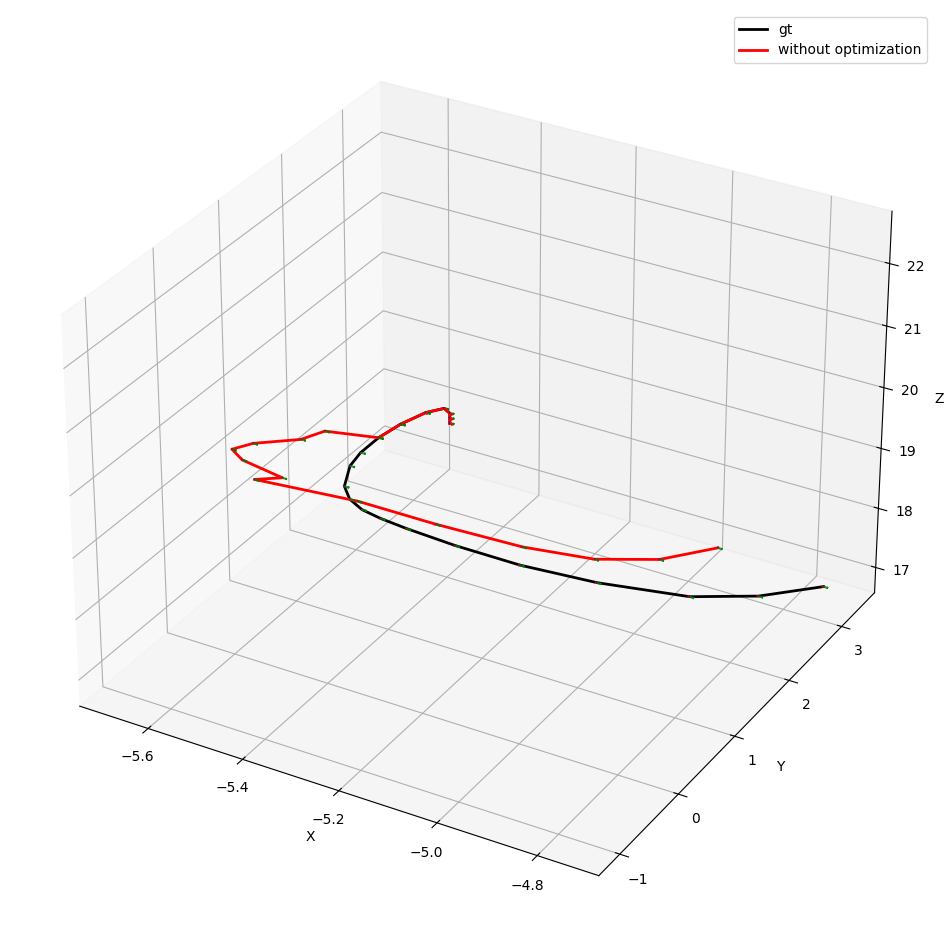

In [17]:
# Plot synthetic data

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

plot_trajectory_with_axes(poses_gt, ax, axis_length=0.01, label='gt', color = 'black', skip=1)
plot_trajectory_with_axes(poses_noise, ax, axis_length=0.01, label='without optimization', color = 'red', skip=1)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

## Run Bundle Adjustemnt

Loss 0 iter: 0.3069 | r err: 0.2759 | theta err: 0.8706
Loss 1 iter: 0.3857 | r err: 0.2208 | theta err: 1.0918
Loss 2 iter: 0.2263 | r err: 0.1716 | theta err: 0.7419
Loss 3 iter: 0.1584 | r err: 0.1471 | theta err: 0.5753
Loss 4 iter: 0.1558 | r err: 0.1411 | theta err: 0.5809
Loss 5 iter: 0.1587 | r err: 0.1468 | theta err: 0.5910
Loss 6 iter: 0.1578 | r err: 0.1471 | theta err: 0.5892
Loss 7 iter: 0.1394 | r err: 0.1440 | theta err: 0.5448
Loss 8 iter: 0.1155 | r err: 0.1422 | theta err: 0.4829
Loss 9 iter: 0.0991 | r err: 0.1400 | theta err: 0.4382


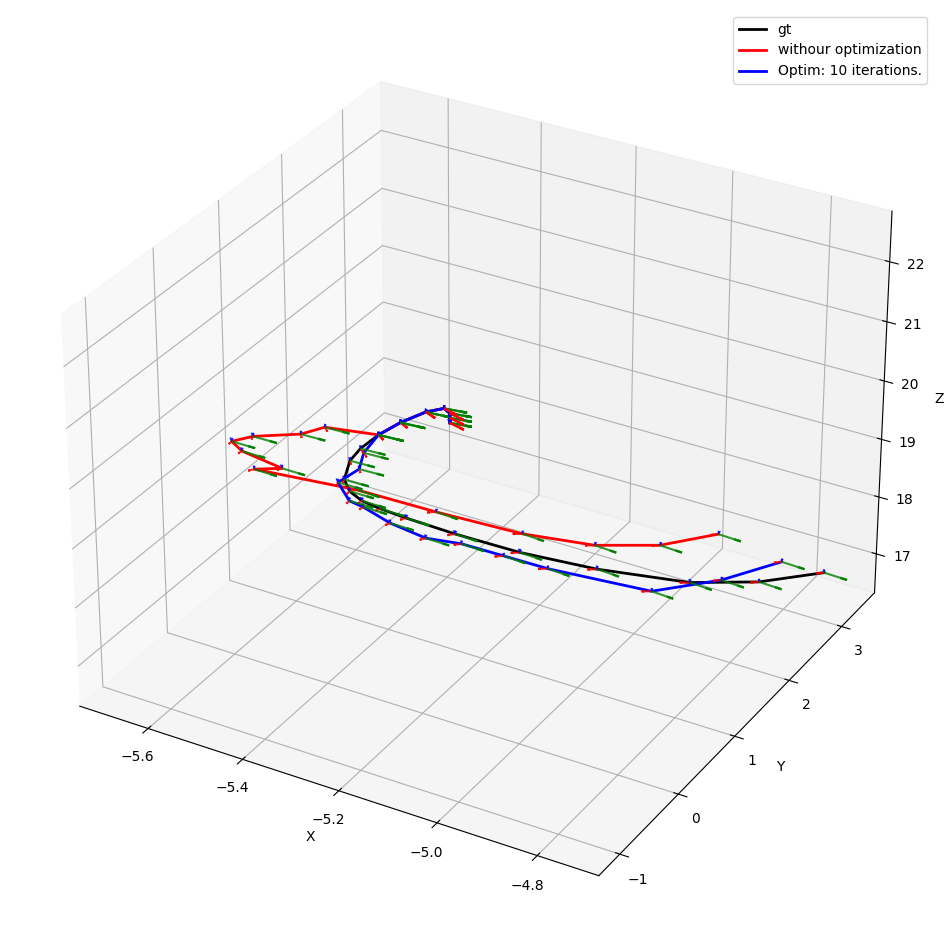

Initialization time: 0.010992288589477539
Mean optim iter time: 0.03698389530181885
Total optim time: 0.3698389530181885


In [30]:

# === Set parameters === 

MAX_ITERATION_TRAIN = 10 # max iteration of bundle adjustment in train mode
MAX_ITERATION_EVAL = 15 # max iteration of bundle adjustment in evaluation mode
PATIENCE = 5 # early stopping patience

STEP_TRANSLATION = 0.1 # inital lr for optimization for translation
STEP_ROTATION = 0.01 # inital lr for optimization for rotation
STEP_ELEV = 0.01  # inital lr for optimization for elevation angle

FREEZE_POSES = 7 # number of poses to not change while optimization, min 1.

iter_num_max = MAX_ITERATION_TRAIN

t_init_start = time.time()

BA = BundleAdjustment(poses_noise.detach().clone(),
                    coords_r_theta.detach().clone(), coords_phi.detach().clone(), 
                    source_poses_idx.detach(), target_poses_idx.detach(), patch_idx.detach(),
                    delta.detach(), weights.detach(), 
                    sonar_config, FREEZE_POSES)
BA.to(device)

# torch.cuda.synchronize()
t_init_end = time.time()

t_optim_start = time.time()


with torch.no_grad():
    poses_optimized, elevation_optimized = BA.run(max_iter=iter_num_max, patience = PATIENCE, min_delta = 0.0007,
                                                    lr_elev=STEP_ELEV, lr_rot=STEP_ROTATION, lr_trans = STEP_TRANSLATION,
                                                    disp_stats=True)

# torch.cuda.synchronize()
t_optim_end = time.time()


fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

plot_trajectory_with_axes(poses_gt, ax, axis_length=0.05, label='gt', color = 'black', skip=1)
plot_trajectory_with_axes(poses_noise, ax, axis_length=0.05, label='withour optimization', color = 'red', skip=1)
plot_trajectory_with_axes(poses_optimized, ax, axis_length=0.05, label=f'Optim: {iter_num_max} iterations.', color = 'blue', skip=1)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

print(f'Initialization time: {t_init_end - t_init_start}')
print(f'Mean optim iter time: {(t_optim_end - t_optim_start)/iter_num_max}')
print(f'Total optim time: {(t_optim_end - t_optim_start)}')




# plt.figure(figsize=(10, 8))

# gt_x = poses_gt[0, :, 0].detach().cpu().numpy()
# gt_y = poses_gt[0, :, 1].detach().cpu().numpy()

# noise_x = poses_noise[0, :, 0].detach().cpu().numpy()
# noise_y = poses_noise[0, :, 1].detach().cpu().numpy()

# opt_x = poses_optimized[0, :, 0].detach().cpu().numpy()
# opt_y = poses_optimized[0, :, 1].detach().cpu().numpy()

# plt.plot(gt_x, gt_y, label='Ground Truth', color='black', linestyle='-', linewidth=2)
# plt.plot(noise_x, noise_y, label='Noisy Odometry', color='red', linestyle='-', linewidth=1.5)
# plt.plot(opt_x, opt_y, label='Optimized Odometry', color='blue', linestyle='-', linewidth=1.5)

# plt.legend()
# plt.axis('equal')
# plt.show()


## Parameter identification

In [38]:
from scipy.spatial.transform import Rotation as R

# read data from example of sequence
df = pd.read_csv(csv_path)


pose = df[['pos_x', 'pos_y', 'pos_z']].values
delta_pose = pose[1:, :] - pose[:-1, :]
relative_pose_change = np.linalg.norm(delta_pose, axis=-1)

print(f'Relative pose change: \n     mean: {np.mean(relative_pose_change)} [m]\n     std: {np.std(relative_pose_change)} [m]')


quaternion = df[['quat_w', 'quat_x', 'quat_y', 'quat_z']].values # ! Scipy use w, x, y, z quaternion
norm = np.linalg.norm(quaternion, axis=-1, keepdims=True)
quaternion = quaternion / norm
r2 = R.from_quat(quaternion[1:, :])
r1 = R.from_quat(quaternion[:-1, :])
delta_rot = r2 * r1.inv()
relative_rot_change = delta_rot.magnitude()

print(f'Relative rot change: \n     mean: {np.mean(relative_rot_change)} [rad]\n     std: {np.std(relative_rot_change)} [rad]')




Relative pose change: 
     mean: 0.2693139189511861 [m]
     std: 0.16115884157660446 [m]
Relative rot change: 
     mean: 0.040563275522528176 [rad]
     std: 0.04154666697644233 [rad]


Results of previous analysys of example from dataset:

```
Relative pose change: 
     mean: 0.2693139189511861 [m]
     std: 0.16115884157660446 [m]
Relative rot change: 
     mean: 0.040563275522528176 [rad]
     std: 0.04154666697644233 [rad]
```

If we assume **$k=5$** optimizer steps, learnig rate for each parameter is:

$$
x_{mean} = k * lr_{x} => lr_{x} = \frac{x_{mean}}{k} 
$$

$$
\phi_{mean} = k * lr_{\phi} => lr_{\phi} = \frac{\phi_{mean}}{k} 
$$



To designate

___

## Designation of damping parameters. 

$$
loss = smoth_L1(reprojection\_err) + dx^2
$$

Gradient for big errors, using L1 norm is always **$grad_{L1} = 1.0$**.

Gradient for $dx^2$ is $2 dx$
We don't want to allow optimizer for too big steps. 


If optimizer want to move position with max 


So, when $grad_{L1}$ = 1.0, and optimizer wants to move position


In [42]:

# === learning rates fo Bundle Adjustment optimization ===
print('=== Parameters ===')

opt_steps = 5 # Steps for optimizator
print(f'For {opt_steps} optimizer steps: ')

# --- translation lr --- 
lr_x = np.mean(relative_pose_change) / opt_steps
print(f'> Learning rate LR for translation: {lr_x}')
# --- rotation lr --- 
lr_rot = np.mean(relative_rot_change) / opt_steps
print(f'> Learning rate LR for rotation: {lr_rot}')

=== Parameters ===
For 5 optimizer steps: 
> Learning rate LR for translation: 0.05386278379023722
> Learning rate LR for rotation: 0.008112655104505635
